In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data set

In [3]:
df = pd.read_csv("../data/processed/citibike_final_cleaned.csv")

print("Shape:", df.shape)
df.head()

C:\Users\MY PC\AppData\Local\Temp\ipykernel_13092\1970785592.py:1: DtypeWarning: Columns (0: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/citibike_final_cleaned.csv")


Shape: (5238215, 24)


,ride_id,rideable_type,started_at,ended_at,trip_duration_min,trip_distance_km,member_casual,start_station_id,start_station_name,start_lat,...,end_lat,end_lng,end_capacity,hour,day_of_week,is_weekend,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,19AE6A4FF06F412F,electric_bike,2026-07-21 20:41:12.464,2026-07-21 20:50:09.456,8.949867,1.399493,member,6483.06,W 36 St & 7 Ave,40.752149,...,40.740259,-73.984092,NaN,20,Tuesday,False,24.9,89,0.5,13.1
1,2FFEFDA0732D107C,electric_bike,2026-07-20 18:29:27.483,2026-07-20 18:59:39.567,30.201400,4.403046,member,3993.03,Sterling Pl & Bedford Ave,40.672695,...,40.710190,-73.937340,NaN,18,Monday,False,27.2,35,0.0,12.2
2,27071C9A36571492,electric_bike,2026-07-21 15:31:35.913,2026-07-21 15:35:36.169,4.004267,0.990657,member,4683.02,Emerson Pl & Myrtle Ave,40.693631,...,40.691782,-73.973730,NaN,15,Tuesday,False,22.9,93,2.7,16.7
3,DB12F248E04AA93A,classic_bike,2026-07-26 22:11:59.009,2026-07-26 22:13:40.687,1.694633,0.251485,member,6417.04,65 St & 35 Ave,40.750530,...,40.748930,-73.899810,NaN,22,Sunday,True,23.8,61,0.0,9.0
4,B21338894CD26018,electric_bike,2026-07-17 21:19:10.032,2026-07-17 21:28:17.408,9.122933,2.008467,member,6650.07,E 55 St & 2 Ave,40.757973,...,40.766040,-73.987370,NaN,21,Friday,False,26.8,44,0.0,7.3


In [6]:
df.shape

(5238215, 24)

In [7]:
df.dtypes

ride_id                     str
rideable_type               str
started_at                  str
ended_at                    str
trip_duration_min       float64
trip_distance_km        float64
member_casual               str
start_station_id            str
start_station_name          str
start_lat               float64
start_lng               float64
start_capacity          float64
end_station_id           object
end_station_name            str
end_lat                 float64
end_lng                 float64
end_capacity            float64
hour                      int64
day_of_week                 str
is_weekend                 bool
temperature_2m          float64
relative_humidity_2m      int64
precipitation           float64
wind_speed_10m          float64
dtype: object

In [5]:
df.duplicated().sum()

np.int64(0)

# Check missing values

In [8]:
missing = df.isnull().sum()

missing[missing > 0]

trip_distance_km        16241
start_station_id         2815
start_station_name       2815
start_lat                2815
start_lng                2815
start_capacity        5238215
end_station_id          13790
end_station_name        12796
end_lat                 13788
end_lng                 13788
end_capacity          5238215
dtype: int64

In [9]:
df.describe()

,trip_duration_min,trip_distance_km,start_lat,start_lng,start_capacity,end_lat,end_lng,end_capacity,hour,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
count,5.238215e+06,5.221974e+06,5.235400e+06,5.235400e+06,0.0,5.224427e+06,5.224427e+06,0.0,5.238215e+06,5.238215e+06,5.238215e+06,5.238215e+06,5.238215e+06
mean,1.358837e+01,2.122737e+00,4.073598e+01,-7.397073e+01,NaN,4.073590e+01,-7.397077e+01,NaN,1.414156e+01,2.625402e+01,6.192131e+01,1.671749e-01,8.598005e+00
std,1.920745e+01,1.804879e+00,4.142336e-02,3.020387e-02,NaN,4.152356e-02,3.028087e-02,NaN,5.247704e+00,3.433994e+00,1.804120e+01,5.968647e-01,3.912564e+00
min,1.000083e+00,0.000000e+00,4.061124e+01,-7.404079e+01,NaN,4.061124e+01,-7.407721e+01,NaN,0.000000e+00,1.680000e+01,2.300000e+01,0.000000e+00,0.000000e+00
25%,5.632383e+00,9.033213e-01,4.071144e+01,-7.399194e+01,NaN,4.071144e+01,-7.399193e+01,NaN,1.000000e+01,2.390000e+01,4.900000e+01,0.000000e+00,5.700000e+00
50%,9.661833e+00,1.590772e+00,4.073481e+01,-7.397873e+01,NaN,4.073522e+01,-7.397855e+01,NaN,1.500000e+01,2.630000e+01,6.100000e+01,0.000000e+00,8.400000e+00
75%,1.664915e+01,2.782932e+00,4.075929e+01,-7.395413e+01,NaN,4.075911e+01,-7.395444e+01,NaN,1.800000e+01,2.850000e+01,7.600000e+01,1.000000e-01,1.100000e+01
max,1.438809e+03,3.523348e+01,4.091239e+01,-7.383226e+01,NaN,4.091239e+01,-7.383226e+01,NaN,2.300000e+01,3.690000e+01,1.000000e+02,1.560000e+01,2.190000e+01


# Trip duration distribution

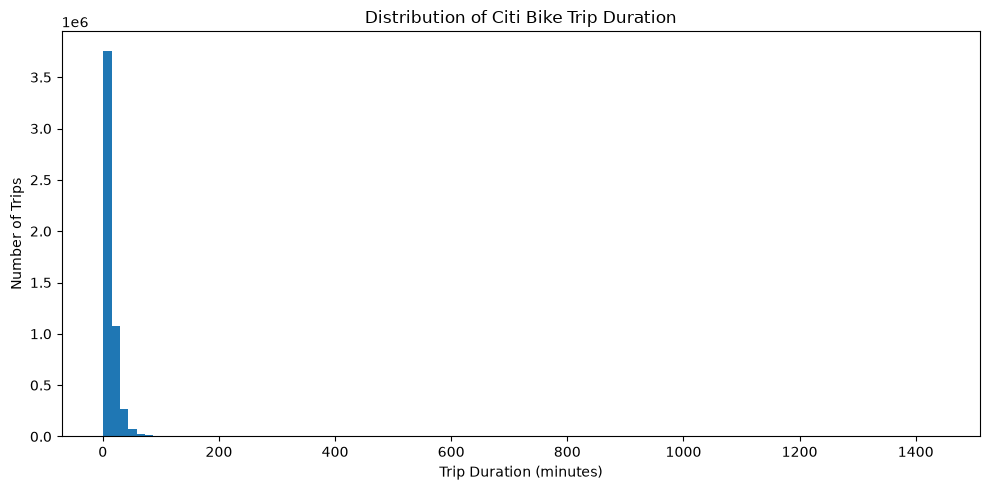

In [19]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["trip_duration_min"],
    bins=100
)

plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Number of Trips")
plt.title("Distribution of Citi Bike Trip Duration")

plt.tight_layout()
plt.savefig("../reports/trip_duration_distribution.png", dpi=300)

plt.show()

# @ Trip distance distribution

# We use .dropna() here because 16,241 trips don't have a calculable distance.

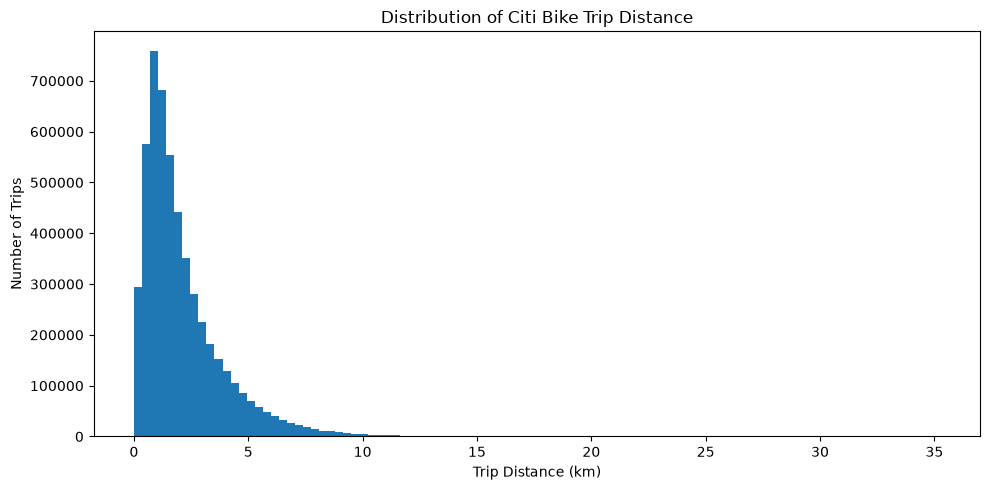

In [20]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["trip_distance_km"].dropna(),
    bins=100
)

plt.xlabel("Trip Distance (km)")
plt.ylabel("Number of Trips")
plt.title("Distribution of Citi Bike Trip Distance")

plt.tight_layout()
plt.savefig("../reports/trip_distance_distribution.png", dpi=300)

plt.show()

# Member vs Casual riders

In [13]:
df["member_casual"].value_counts()

member_casual
member    4143132
casual    1095083
Name: count, dtype: int64

# @ Member vs Casual chart

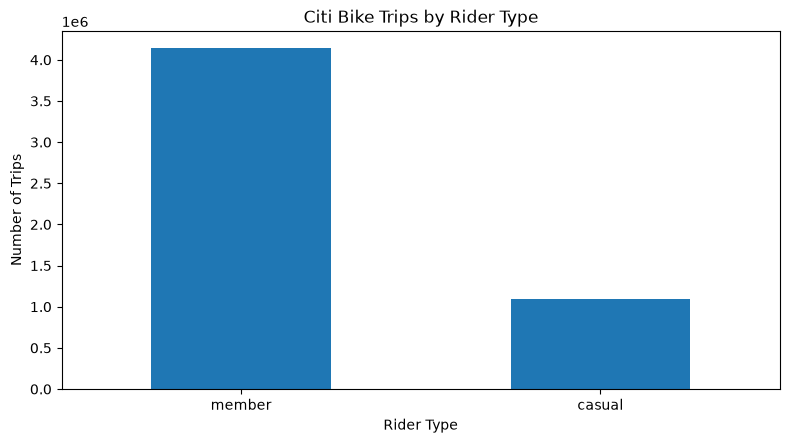

In [21]:
df["member_casual"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Rider Type")
plt.ylabel("Number of Trips")
plt.title("Citi Bike Trips by Rider Type")

plt.tight_layout()
plt.savefig("../reports/trip_distance_distribution.png", dpi=300)
plt.xticks(rotation=0)
plt.show()

# @ Bike type analysis

In [15]:
df["rideable_type"].value_counts()

rideable_type
electric_bike    3845017
classic_bike     1393198
Name: count, dtype: int64

# @ Bike type chart

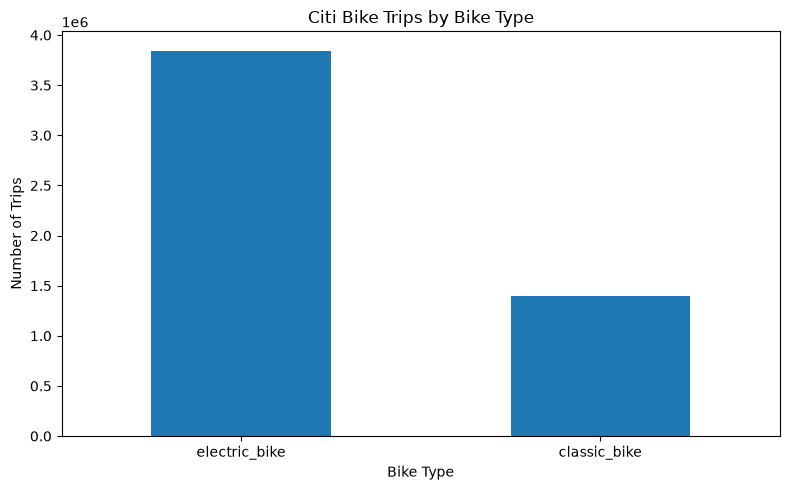

In [23]:
plt.figure(figsize=(8, 5))

df["rideable_type"].value_counts().plot(kind="bar")

plt.xlabel("Bike Type")
plt.ylabel("Number of Trips")
plt.title("Citi Bike Trips by Bike Type")

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("../reports/bike_type_distribution.png", dpi=300)
plt.show()

# @ Trips by Hour

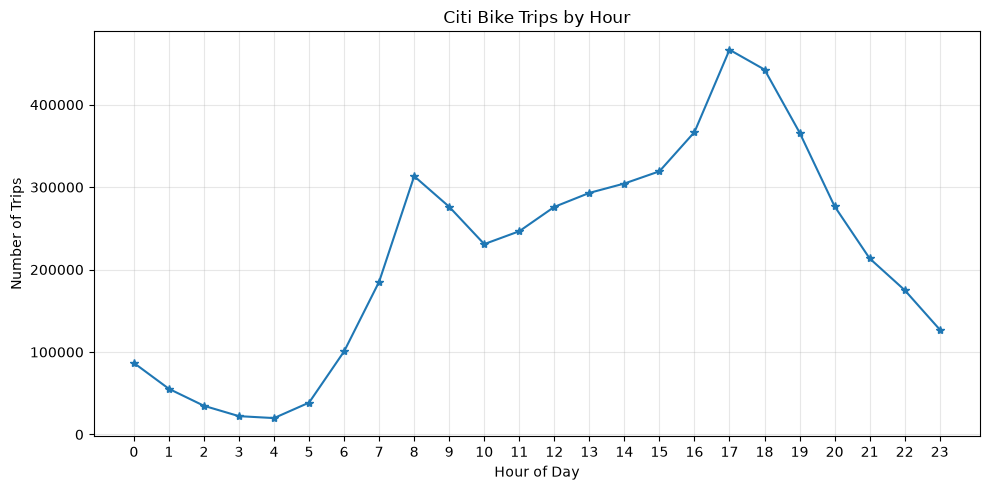

In [26]:
hourly_trips = df["hour"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_trips.index,
    hourly_trips.values,
    marker="*"
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Citi Bike Trips by Hour")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/trips_by_hour.png", dpi=300)

plt.show()

# @ Trips by Day of Week

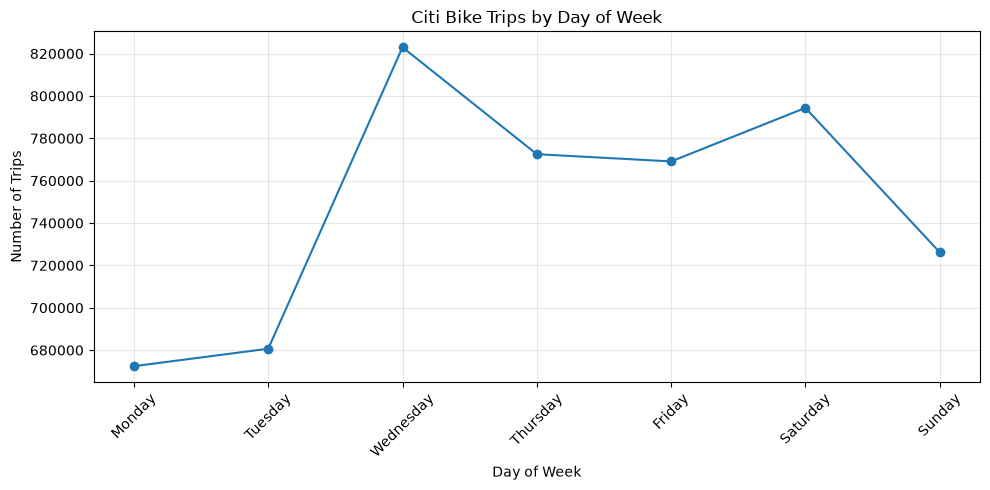

In [27]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

daily_trips = (
    df["day_of_week"]
    .value_counts()
    .reindex(day_order)
)

plt.figure(figsize=(10, 5))

plt.plot(
    daily_trips.index,
    daily_trips.values,
    marker="o"
)

plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")
plt.title("Citi Bike Trips by Day of Week")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/trips_by_day_of_week.png", dpi=300)

plt.show()

# @ Trip Duration by Rider Type

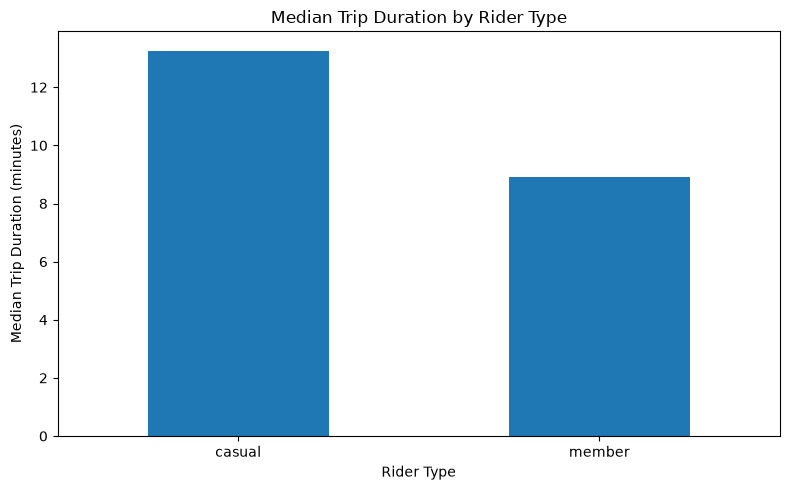

In [28]:
duration_by_rider = (
    df.groupby("member_casual")["trip_duration_min"]
    .median()
)

plt.figure(figsize=(8, 5))

duration_by_rider.plot(kind="bar")

plt.xlabel("Rider Type")
plt.ylabel("Median Trip Duration (minutes)")
plt.title("Median Trip Duration by Rider Type")

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("../reports/trip_duration_by_rider_type.png", dpi=300)

plt.show()

# @ Trip Distance vs Trip Duration

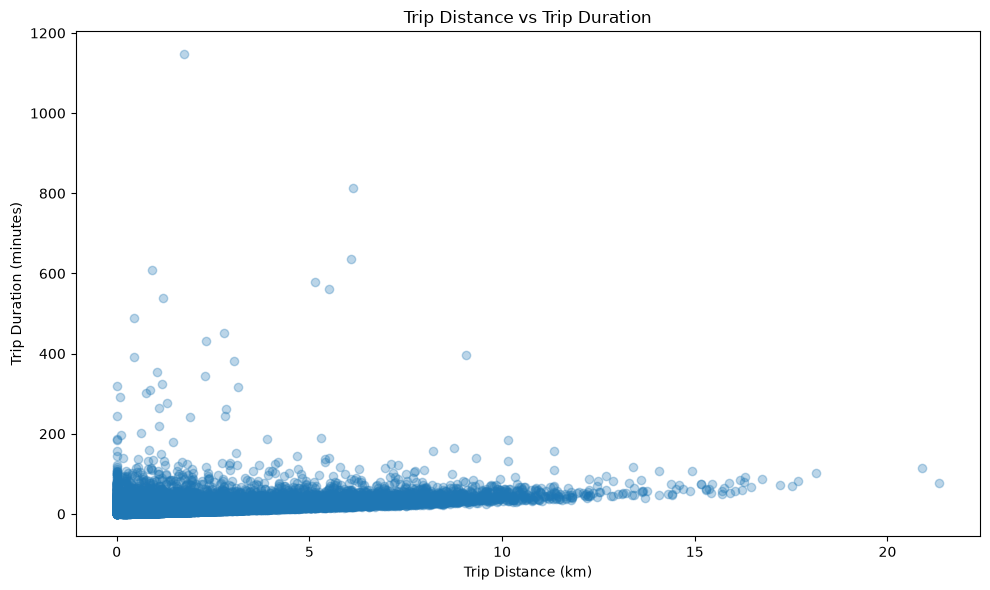

In [29]:
sample_df = df[
    ["trip_distance_km", "trip_duration_min"]
].dropna().sample(50000, random_state=42)

plt.figure(figsize=(10, 6))

plt.scatter(
    sample_df["trip_distance_km"],
    sample_df["trip_duration_min"],
    alpha=0.3
)

plt.xlabel("Trip Distance (km)")
plt.ylabel("Trip Duration (minutes)")
plt.title("Trip Distance vs Trip Duration")

plt.tight_layout()
plt.savefig("../reports/distance_vs_duration.png", dpi=300)

plt.show()

# @ Weekday vs Weekend Trips

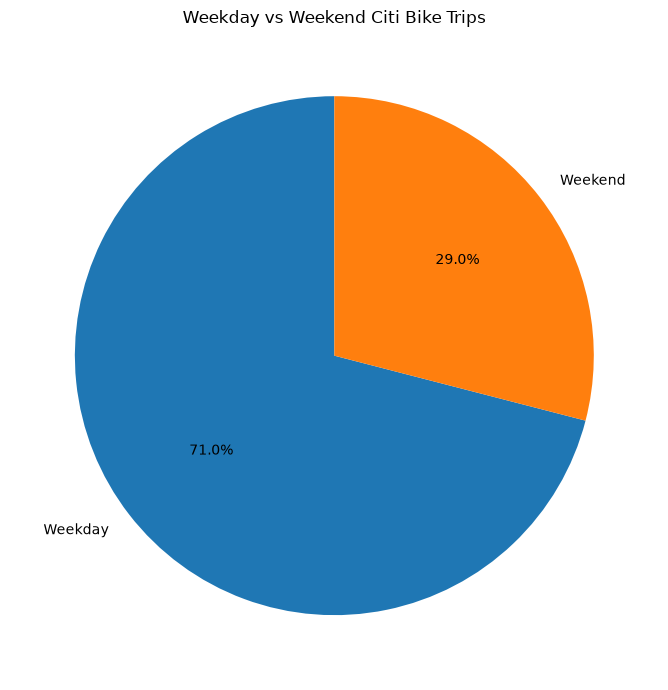

In [30]:
weekend_trips = df["is_weekend"].map({
    False: "Weekday",
    True: "Weekend"
}).value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    weekend_trips.values,
    labels=weekend_trips.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Weekday vs Weekend Citi Bike Trips")

plt.tight_layout()
plt.savefig("../reports/weekday_vs_weekend.png", dpi=300)

plt.show()

# @ Weather vs Trip Count

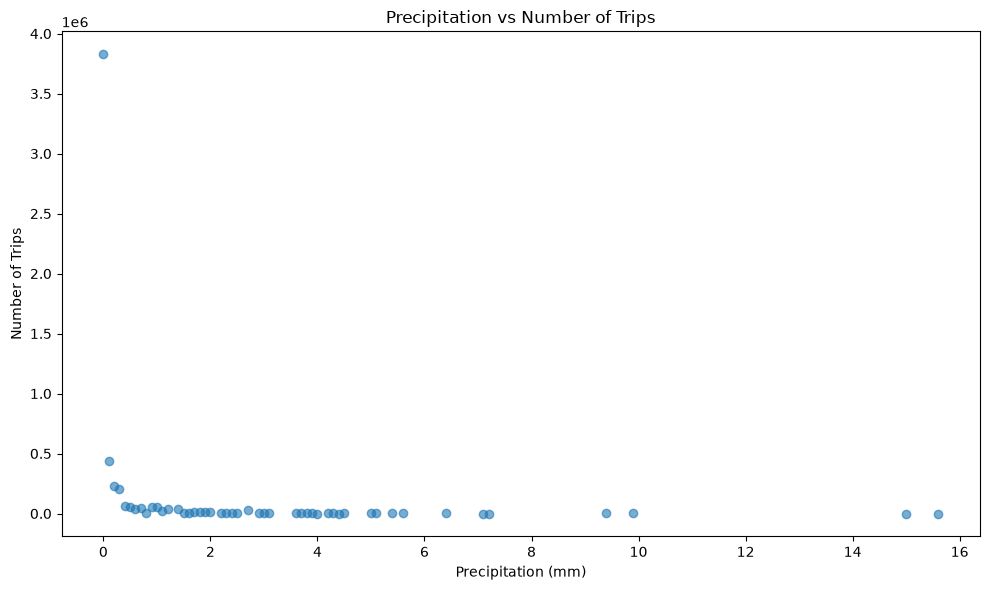

In [31]:
weather_trips = (
    df.groupby("precipitation")
    .size()
    .reset_index(name="trip_count")
)

plt.figure(figsize=(10, 6))

plt.scatter(
    weather_trips["precipitation"],
    weather_trips["trip_count"],
    alpha=0.6
)

plt.xlabel("Precipitation (mm)")
plt.ylabel("Number of Trips")
plt.title("Precipitation vs Number of Trips")

plt.tight_layout()
plt.savefig("../reports/precipitation_vs_trips.png", dpi=300)

plt.show()

# @ Top 10 Start Stations

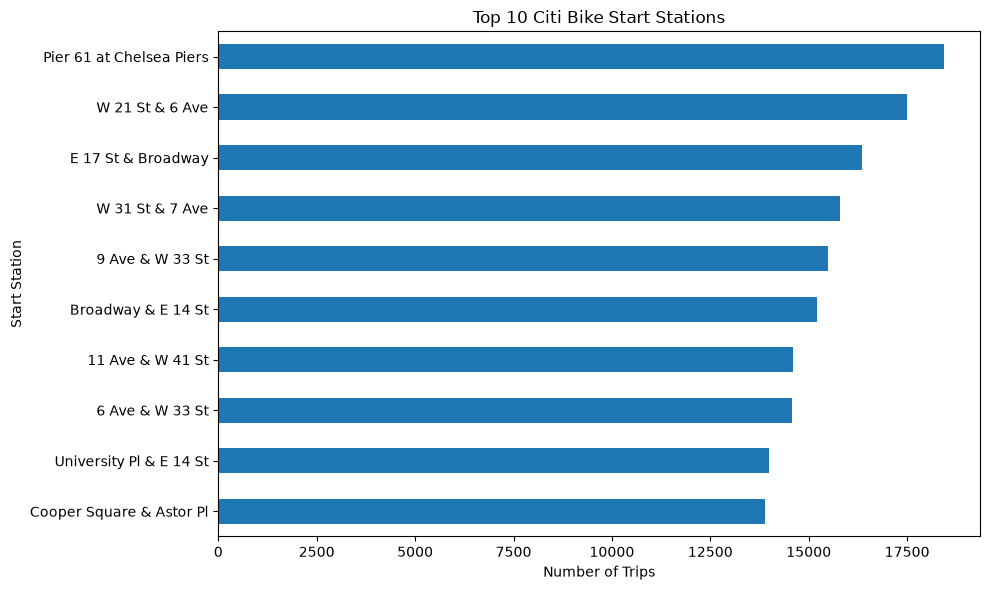

In [32]:
top_stations = (
    df["start_station_name"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

top_stations.plot(kind="barh")

plt.xlabel("Number of Trips")
plt.ylabel("Start Station")
plt.title("Top 10 Citi Bike Start Stations")

plt.tight_layout()
plt.savefig("../reports/top_10_start_stations.png", dpi=300)

plt.show()

# @ Trip Duration Distribution — Up to 60 Minutes

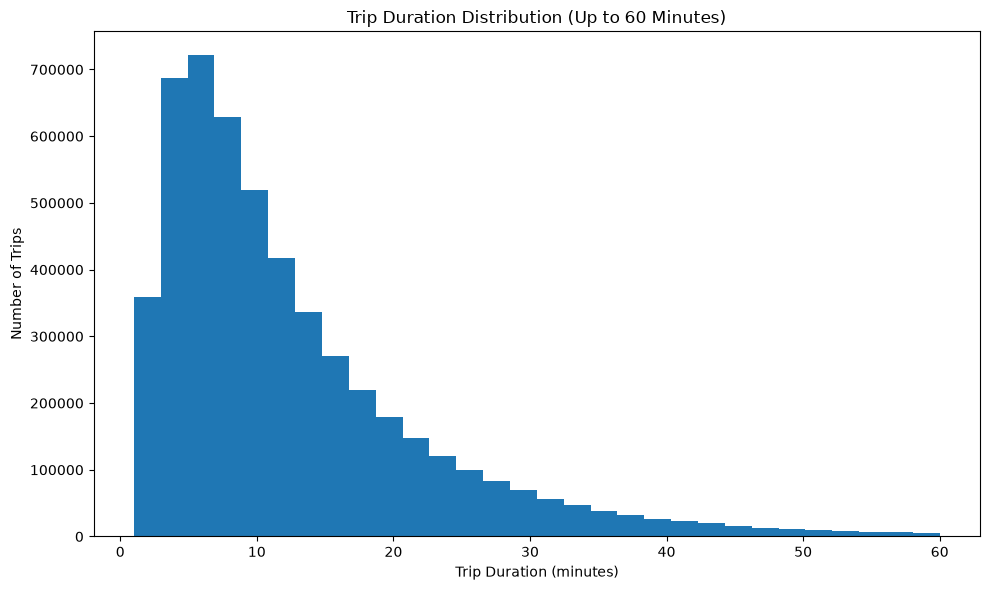

In [33]:
duration_data = df.loc[
    df["trip_duration_min"] <= 60,
    "trip_duration_min"
].dropna()

plt.figure(figsize=(10, 6))

plt.hist(
    duration_data,
    bins=30
)

plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Number of Trips")
plt.title("Trip Duration Distribution (Up to 60 Minutes)")

plt.tight_layout()
plt.savefig("../reports/trip_duration_up_to_60min.png", dpi=300)

plt.show()